# Qualitative visualizations of approach

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.metrics import calculate_coalescent_information_ratio_at_MAP, calculate_rel_mean_shift, calculate_rel_mean_shift_const, calculate_rel_mode_shift, calculate_rel_median_shift, calculate_rel_wasserstein_dist, calculate_rel_wasserstein2_dist, calculate_mode_shift, calculate_median_shift
from src.evaluate_prior_impact import create_prior_influence_metric_df_const, create_prior_influence_metric_df_exp, create_prior_influence_metric_df_bottleneck, create_prior_influence_metric_df_const_pathogen, create_prior_influence_metric_df_pathogen_exp, create_prior_influence_metric_df_exp_pathogen, create_prior_influence_metric_df_bottleneck_pathogen
from src.prob_functions import likelihood_tMRCA_mutations, coalescent_prior, coalescent_prior_bottleneck, coalescent_prior_expN_present, coalescent_prior_expN
from src.plotting.plot_prob_functions import plot_tMRCA_constN, plot_tMRCA_expN_present, plot_tMRCA_expN, plot_tMRCA_bottleneck
from src.plotting.plot_metric_comparison import plot_error_metrics_const, plot_error_metrics_exp, plot_bottleneck_error_metrics_by_depth, plot_bottleneck_error_metrics_by_duration, plot_bottleneck_heatmaps, plot_error_heatmaps, plot_error_metrics_by_beta, plot_error_metrics_exp_all_metrics_per_subplot, plot_metrics_by_alpha_const, plot_error_metrics_by_beta_pathogen, plot_mode_shift_pathogen_summary, plot_metric_summary, plot_pathogen_error_summary

## Exemplary likelihood curves

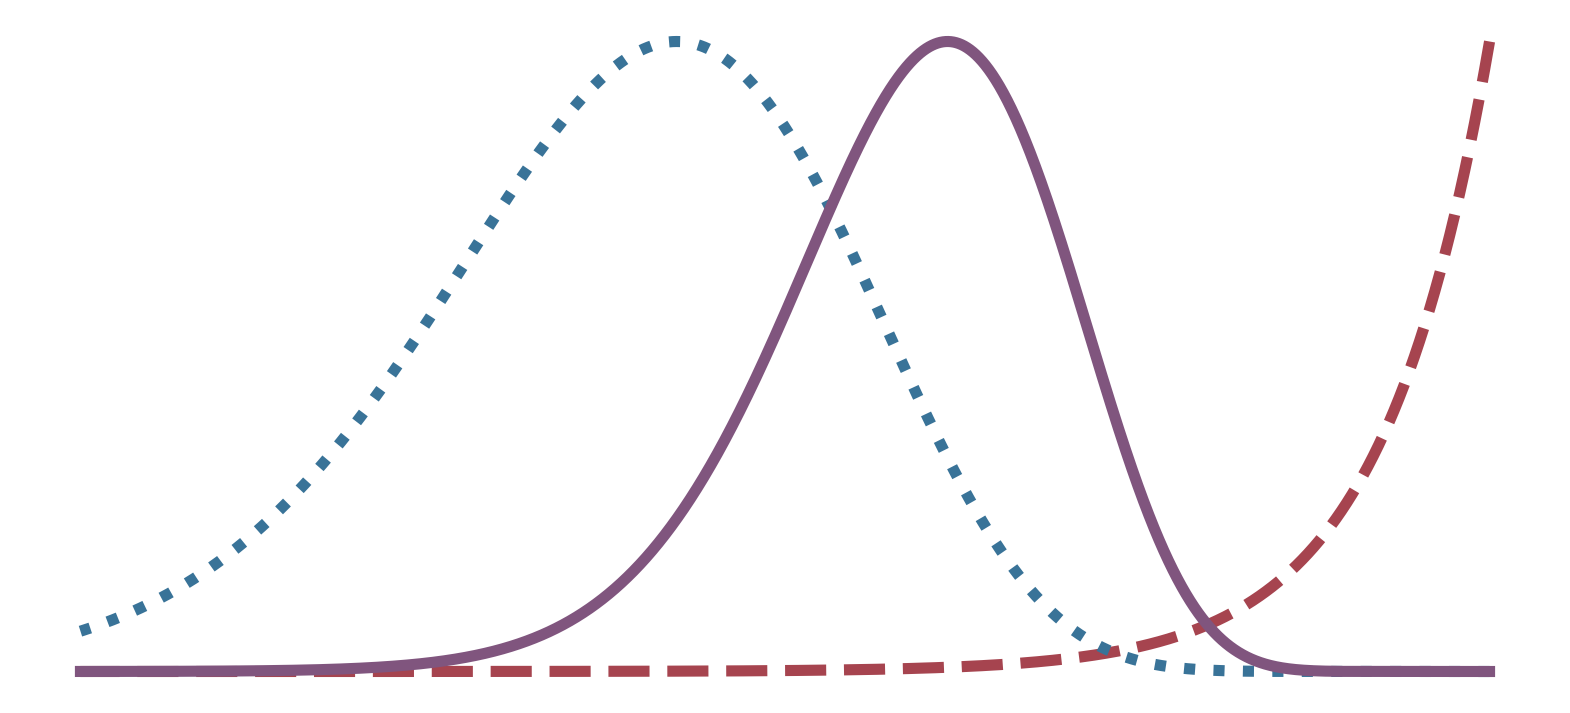

In [9]:
def plot_tMRCA_constN(N_values, alpha_values, base_mu, base_k, t_max, L, time_scale="days", title=None):

    t_values = np.linspace(0, t_max, t_max * 10)

    colors = ["#a6444f", "#397398", "#80557e"]  # Prior, Likelihood, Posterior

    fig, axs = plt.subplots(len(N_values), len(alpha_values), figsize=(20, 9), sharex=False, sharey=False)

    if len(N_values) == 1 and len(alpha_values) == 1:
        axs = np.array([[axs]])
    elif len(N_values) == 1:
        axs = np.expand_dims(axs, axis=0)
    elif len(alpha_values) == 1:
        axs = np.expand_dims(axs, axis=1)

    for row, N in enumerate(N_values):
        for col, alpha in enumerate(alpha_values):
            mu = base_mu * alpha
            k_mut = max(int(base_k * alpha), 1)

            likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
            priors = np.array([coalescent_prior(t, N) for t in t_values])
            posteriors = likelihoods * priors

            # Normalize to proper distributions
            #likelihoods /= np.trapezoid(likelihoods, t_values) if np.trapezoid(likelihoods, t_values) > 0 else 1
            #priors /= np.trapezoid(priors, t_values) if np.trapezoid(priors, t_values) > 0 else 1
            #posteriors /= np.trapezoid(posteriors, t_values) if np.trapezoid(posteriors, t_values) > 0 else 1

            # Normalize
            likelihoods /= np.max(likelihoods) if np.max(likelihoods) > 0 else 1
            priors /= np.max(priors) if np.max(priors) > 0 else 1
            posteriors /= np.max(posteriors) if np.max(posteriors) > 0 else 1

            ax = axs[row, col]
            ax.plot(t_values, priors, linestyle="--", color=colors[0], label="Prior", linewidth = 8)
            ax.plot(t_values, likelihoods, linestyle=":", color=colors[1], label="Likelihood", linewidth = 8)
            ax.plot(t_values, posteriors, color=colors[2], label="Posterior", linewidth = 8)
            ax.invert_xaxis()
            ax.grid(False)

            
            ax.set_xlabel(f"tMRCA [{time_scale}]", fontsize=26)

            ax.set_ylabel(f"Rel. prob. (scaled by max.)", fontsize=26)
            ax.tick_params(axis='both', which='major', labelsize=18)

            #ax.legend(loc="upper right", fontsize=40, title_fontsize=24)

            
    if title == None:
        title = "Prior, Likelihood, and Posterior of tMRCA at varying N and α"
    plt.axis("off")

    plt.suptitle(title, fontsize=16)
    #plt.savefig("figures/posterior.svg", transparent=True, bbox_inches="tight")
    plt.show()

# Setup parameters
L = 100
N_values = [100, 1000, 10000]  # Rows
alpha_values = [0.1, 1, 10]  # Columns
base_mu = 0.0001
base_k = 10
t_max = 2000  # Maximum tMRCA to consider


plot_tMRCA_constN([100], [1], base_mu, 15, 1300, L, title = "")

Choice of k to get expected t_MRCA of around 200 years: 202


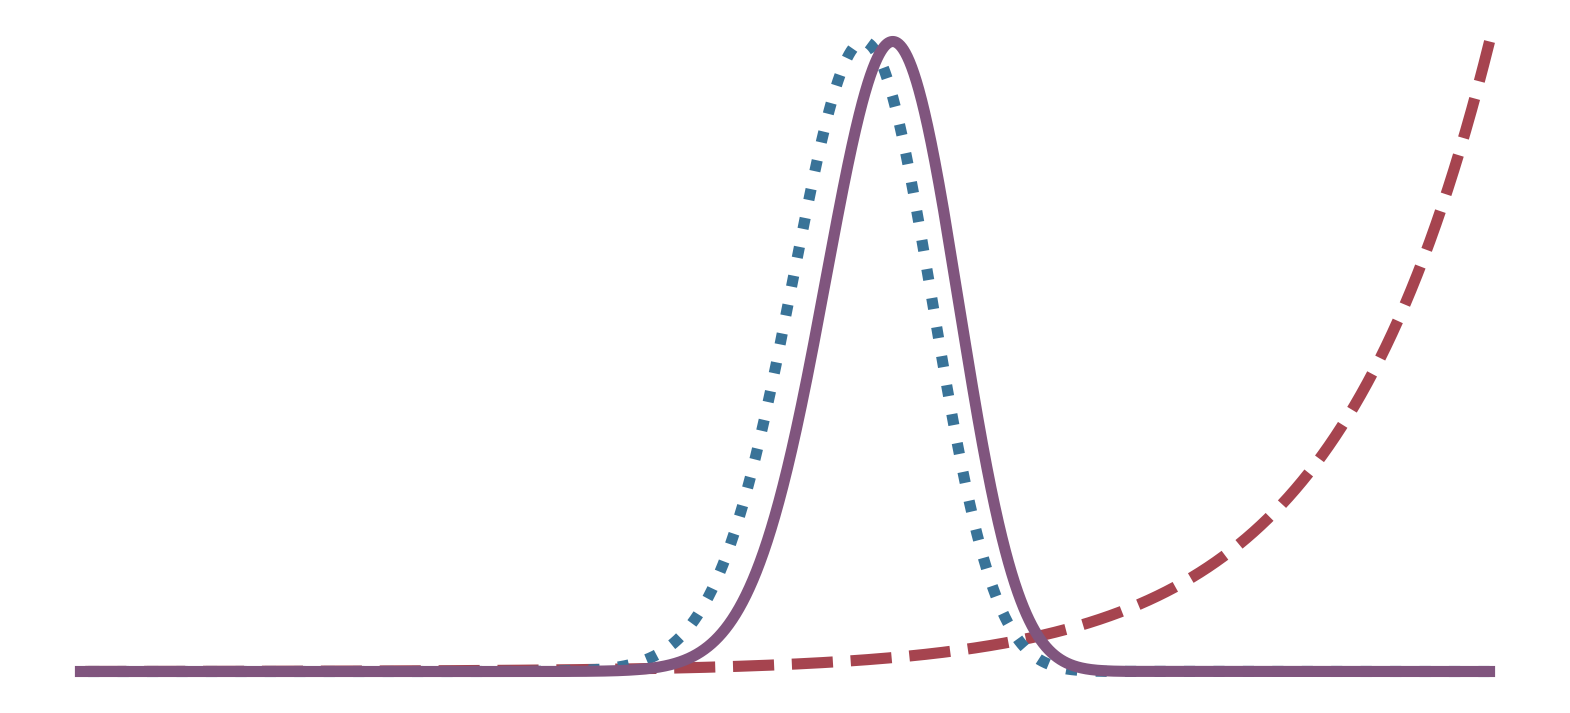

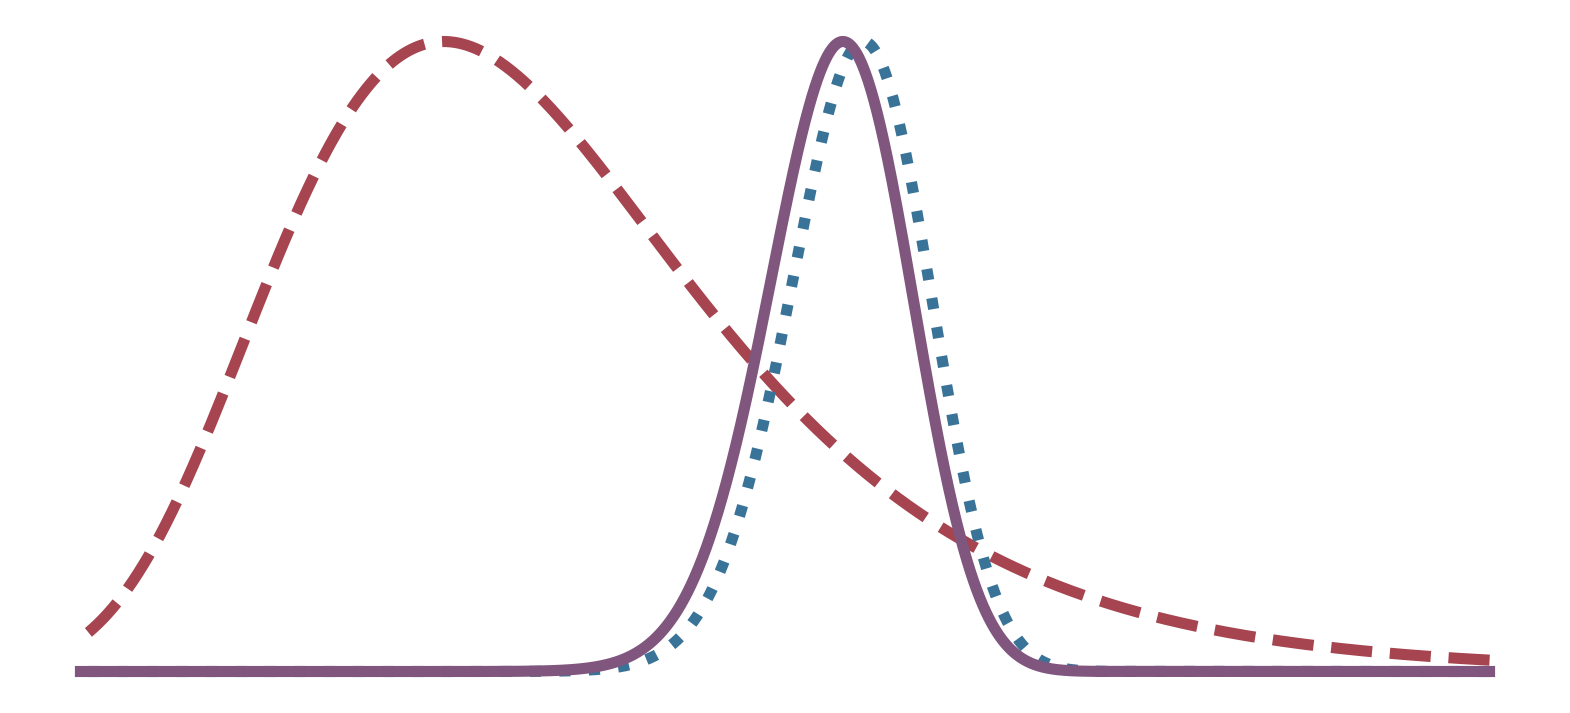

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tMRCA_expN_present(
    mu,
    L,
    k_mut,
    N_present,
    beta_vec,
    max_tmrca,
    time_scale="days",
    title="",
    axis_off=True,
    save_path=None,
):
    t_values = np.linspace(0, max_tmrca, max_tmrca * 10)

    colors = {
        "prior": "#a6444f",
        "likelihood": "#397398",
        "posterior": "#80557e",
    }

    fig, axs = plt.subplots(1, len(beta_vec), figsize=(20, 9), sharey=False)

    if len(beta_vec) == 1:
        axs = [axs]

    for col, beta in enumerate(beta_vec):
        likelihoods = np.array([
            likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values
        ])
        priors_expN = np.array([
            coalescent_prior_expN_present(t, N_present, beta) for t in t_values
        ])
        posteriors_expN = likelihoods * priors_expN

        # normalize for visual comparison
        likelihoods /= np.max(likelihoods) if np.max(likelihoods) > 0 else 1
        priors_expN /= np.max(priors_expN) if np.max(priors_expN) > 0 else 1
        posteriors_expN /= np.max(posteriors_expN) if np.max(posteriors_expN) > 0 else 1

        ax = axs[col]
        
        ax.plot(
            t_values, priors_expN,
            linestyle="--",
            color=colors["prior"],
            label="Prior",
            linewidth=8
        )
        ax.plot(
            t_values, likelihoods,
            linestyle=":",
            color=colors["likelihood"],
            label="Likelihood",
            linewidth=8
        )
        
        ax.plot(
            t_values, posteriors_expN,
            color=colors["posterior"],
            label="Posterior",
            linewidth=8
        )
        
        ax.invert_xaxis()
        ax.grid(False)
        #ax.set_title(rf"$\beta = {beta}$", fontsize=22)
        ax.set_xlabel(f"tMRCA [{time_scale}]", fontsize=22)
        ax.set_ylabel("Rel. prob. (scaled by max.)", fontsize=22)
        ax.tick_params(axis="both", which="major", labelsize=16)

        if axis_off:
            ax.axis("off")

    if title:
        plt.suptitle(title, fontsize=18)

    if save_path is not None:
        plt.savefig(save_path, transparent=True, bbox_inches="tight")

    plt.show()

beta_vec_tuberculosis = [0.015]  # Growth rates for M. tuberculosis, in units of 1/year
N_present = 10000

mu_tuberculosis = 4.5 * 10**-8  # Approximate mutation rate for Mycobacterium tuberculosis per site per year
L_tuberculosis = 4500000  # Approximate genome length of M. tuberculosis
t_max_tuberculosis = 450

print("Choice of k to get expected t_MRCA of around 200 years: " + str(int(500 * mu_tuberculosis * L_tuberculosis * 2)))  # Expected number of mutations in a 500 year old M. tuberculosis sample
k_tuberculosis = int(200 * mu_tuberculosis * L_tuberculosis * 2)

plot_tMRCA_constN([50], [1], mu_tuberculosis, k_tuberculosis, t_max_tuberculosis, L_tuberculosis, title = "")
plot_tMRCA_expN_present(
    mu=mu_tuberculosis,
    L=L_tuberculosis,
    k_mut=k_tuberculosis,
    N_present=N_present,
    beta_vec=beta_vec_tuberculosis,
    max_tmrca=t_max_tuberculosis,
    title="",
    axis_off=True,
    #save_path="figures/posterior_exp.svg"
)

## Coalescent visualization

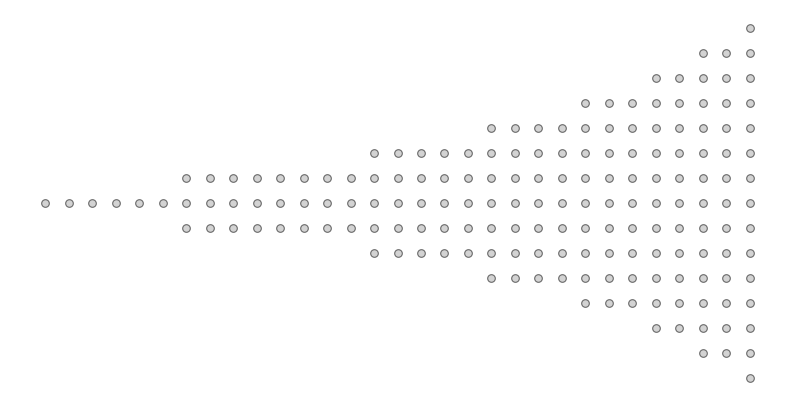

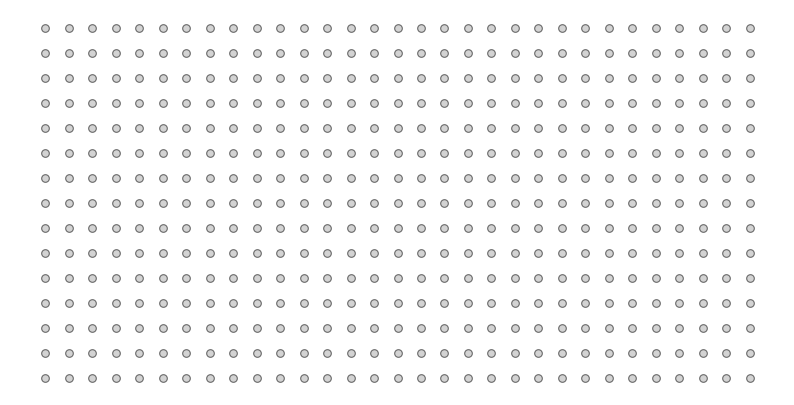

In [11]:
# ----- parameters -----
x_min, x_max = 0, 60
dx = 2.0
dy = 1.5
a = 1.0
b = 0.04
fig_scale = 1.0

# ----- exponential boundary -----
def boundary(x):
    return a * np.exp(b * x)

# ----- shared grid -----
x_vals = np.arange(x_min, x_max + dx, dx)
y_max = boundary(x_max)
y_vals = np.arange(-np.ceil(y_max), np.ceil(y_max) + dy, dy)

# =======================
# EXPONENTIAL CASE
# =======================
xs = []
ys = []

for y in y_vals:
    for x in x_vals:
        if abs(y) <= boundary(x):
            xs.append(x)
            ys.append(y)

plt.figure(figsize=(10 * fig_scale, 5 * fig_scale))
plt.scatter(
    xs,
    ys,
    s=30,
    facecolors="lightgrey",
    edgecolors="dimgray",
    linewidths=0.8
)
plt.axis("off")
plt.savefig("figures/exp_points.svg", transparent=True, bbox_inches="tight")

plt.show()


# =======================
# NON-GROWING CASE
# =======================
xs = []
ys = []

for y in y_vals:
    for x in x_vals:
        if abs(y) <= y_max:
            xs.append(x)
            ys.append(y)

plt.figure(figsize=(10 * fig_scale, 5 * fig_scale))
plt.scatter(
    xs,
    ys,
    s=30,
    facecolors="lightgrey",
    edgecolors="dimgray",
    linewidths=0.8
)
plt.axis("off")
plt.savefig("figures/const_points.svg", transparent=True, bbox_inches="tight")

plt.show()

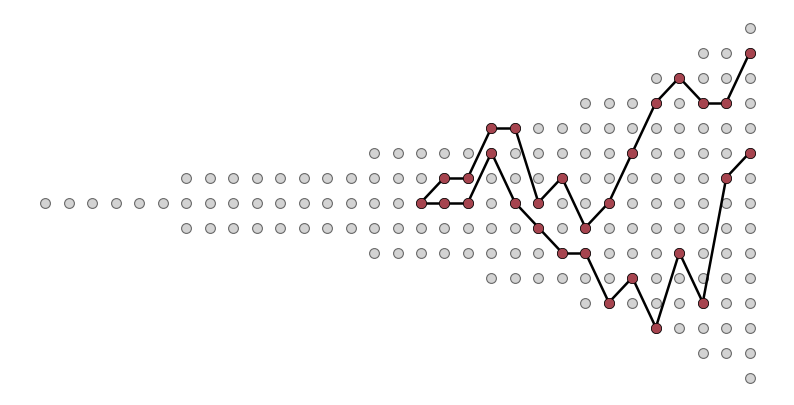

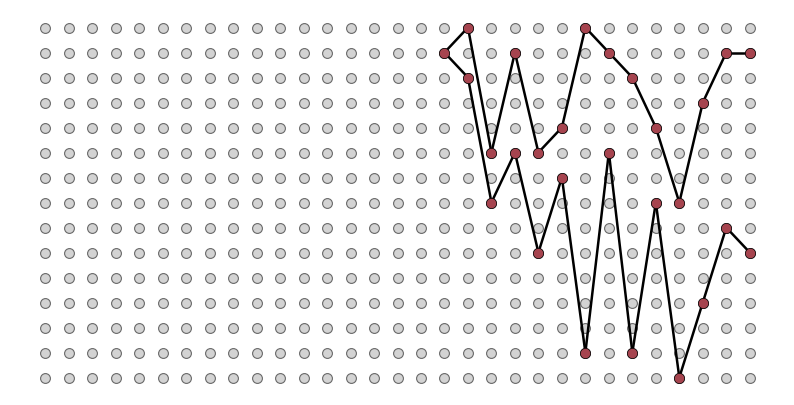

In [13]:
# ----- parameters -----
x_min, x_max = 0, 60
dx = 2.0
dy = 1.5
a = 1.0
b = 0.04
fig_scale = 1.0

# coalescent parameters
n_lines_exp = 15          # exactly 15 vertical lines colored
n_lines_const = 14        # exactly 14 vertical lines colored
seed = 7
line_width = 1.8
red_size = 55

# ----- exponential boundary -----
def boundary(x):
    return a * np.exp(b * x)

# ----- shared grid -----
x_vals = np.arange(x_min, x_max + dx, dx)
y_max = boundary(x_max)
y_vals = np.arange(-np.ceil(y_max), np.ceil(y_max) + dy, dy)


def build_points(case="exp"):
    xs, ys = [], []
    points_by_x = {}

    for x in x_vals:
        valid_y = []
        for y in y_vals:
            if case == "exp":
                ok = abs(y) <= boundary(x)
            elif case == "const":
                ok = abs(y) <= y_max
            else:
                raise ValueError("case must be 'exp' or 'const'")

            if ok:
                xs.append(x)
                ys.append(y)
                valid_y.append(y)

        points_by_x[x] = np.array(sorted(valid_y))

    return xs, ys, points_by_x


def nearest_available(y_candidates, target):
    idx = np.argmin(np.abs(y_candidates - target))
    return y_candidates[idx]


def generate_coalescent(points_by_x, n_lines, rng):
    """
    Use exactly n_lines vertical columns, from right to left.
    In the first n_lines-1 columns: 2 red points.
    In the last column: 1 red point.
    """
    if n_lines < 2:
        raise ValueError("n_lines must be at least 2.")

    if n_lines > len(x_vals):
        raise ValueError("n_lines is larger than the number of available x-columns.")

    active_x = sorted(x_vals[-n_lines:], reverse=True)  # rightmost n_lines columns

    red_points = {}
    segments = []

    # rightmost column: choose 2 random red points
    x_right = active_x[0]
    y_choices = points_by_x[x_right]
    if len(y_choices) < 2:
        raise ValueError(f"Not enough points at x={x_right} to place two red dots.")
    current_two = np.sort(rng.choice(y_choices, size=2, replace=False))
    red_points[x_right] = current_two

    # middle columns: 2 red points each
    for i, x in enumerate(active_x[1:-1], start=1):
        y_choices = points_by_x[x]
        if len(y_choices) < 2:
            raise ValueError(f"Not enough points at x={x} to place two red dots.")

        new_two = np.sort(rng.choice(y_choices, size=2, replace=False))
        red_points[x] = new_two

        x_prev = active_x[i - 1]
        segments.append(((x_prev, current_two[0]), (x, new_two[0])))
        segments.append(((x_prev, current_two[1]), (x, new_two[1])))

        current_two = new_two

    # last column: only 1 red point
    x_last = active_x[-1]
    y_choices = points_by_x[x_last]
    midpoint = np.mean(current_two)
    y_single = nearest_available(y_choices, midpoint)
    red_points[x_last] = np.array([y_single])

    x_prev = active_x[-2]
    segments.append(((x_prev, current_two[0]), (x_last, y_single)))
    segments.append(((x_prev, current_two[1]), (x_last, y_single)))

    return red_points, segments


def plot_case(case, n_lines, outfile, seed_offset=0):
    xs, ys, points_by_x = build_points(case=case)

    rng = np.random.default_rng(seed + seed_offset)
    red_points, segments = generate_coalescent(points_by_x, n_lines, rng)

    plt.figure(figsize=(10 * fig_scale, 5 * fig_scale))

    # grey points
    plt.scatter(
        xs,
        ys,
        s=50,
        facecolors="lightgrey",
        edgecolors="dimgray",
        linewidths=0.8,
        zorder=1
    )

    # black lines
    for (x1, y1), (x2, y2) in segments:
        plt.plot([x1, x2], [y1, y2], color="black", lw=line_width, zorder=2)

    # red points
    red_xs = []
    red_ys = []
    for x, y_arr in red_points.items():
        for y in y_arr:
            red_xs.append(x)
            red_ys.append(y)

    plt.scatter(
        red_xs,
        red_ys,
        s=red_size,
        c="#a6444f",
        edgecolors="black",
        linewidths=0.5,
        zorder=3
    )

    plt.axis("off")
    plt.savefig(outfile, transparent=True, bbox_inches="tight")
    plt.show()


# =======================
# EXPONENTIAL CASE
# =======================
plot_case(
    case="exp",
    n_lines=n_lines_exp,
    outfile="figures/exp_points_with_coalescent.svg",
    seed_offset=0
)

# =======================
# NON-GROWING CASE
# =======================
plot_case(
    case="const",
    n_lines=n_lines_const,
    outfile="figures/const_points_with_coalescent.svg",
    seed_offset=111
)

## Population models

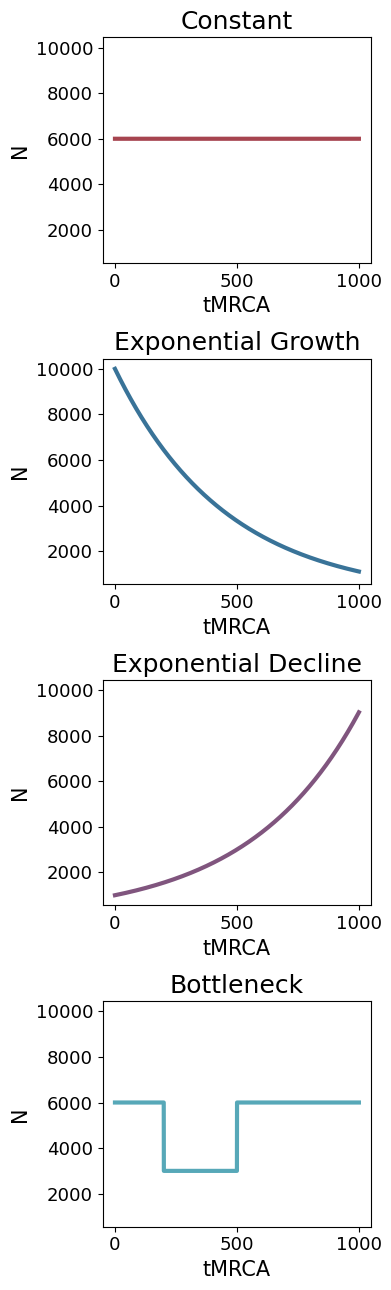

In [14]:
t_max = 1000
N_present = 10000

colors = ["#a6444f", "#397398", "#80557e", "#57a8b8"]  # Constant, Exp. growth, Exp. decline, Bottleneck

t_values = np.linspace(0, t_max, t_max * 10)

# Define models
models = {
    "Constant": np.repeat(6000, len(t_values)),
    "Exponential Growth": N_present * np.exp(-0.0022 * t_values),
    "Exponential Decline": 1000 * np.exp(0.0022 * t_values),
    "Bottleneck": np.where((t_values < 200) | (t_values > 500), 6000, 3000),
}

fig, axes = plt.subplots(4, 1, figsize=(4, 13), sharey=True)

for ax, (title, values), color in zip(axes, models.items(), colors):
    ax.plot(t_values, values, color=color, linewidth=3)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("tMRCA", fontsize=15)
    ax.set_ylabel("N", fontsize=15)
    ax.tick_params(labelleft=True, labelsize=13)

plt.tight_layout()
plt.show()


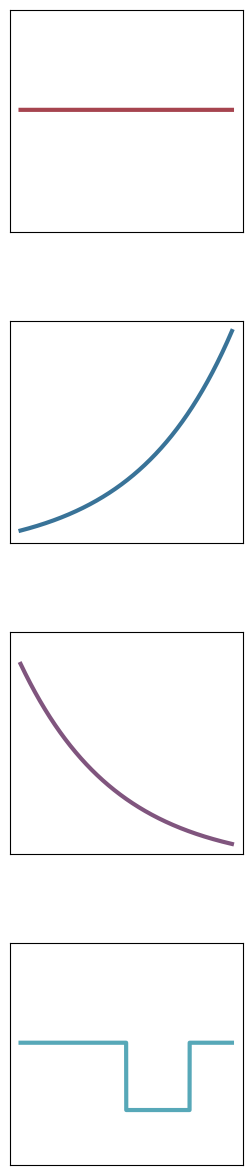

In [15]:
t_max = 1000
N_present = 10000

colors = ["#a6444f", "#397398", "#80557e", "#57a8b8"]  # Constant, Exp. growth, Exp. decline, Bottleneck

t_values = np.linspace(0, t_max, t_max * 10)

# Define models
models = {
    "Constant": np.repeat(6000, len(t_values)),
    "Exponential Growth": N_present * np.exp(-0.0022 * t_values),
    "Exponential Decline": 1000 * np.exp(0.0022 * t_values),
    "Bottleneck": np.where((t_values < 200) | (t_values > 500), 6000, 3000),
}

fig, axes = plt.subplots(4, 1, figsize=(3, 15), sharey=True)

for ax, (title, values), color in zip(axes, models.items(), colors):
    ax.plot(t_values, values, color=color, linewidth=3)
    #ax.set_title(title, fontsize=18)
    ax.set_xlabel("", fontsize=15)
    ax.set_ylabel("", fontsize=15)

    # remove tick labels AND ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.invert_xaxis()

plt.subplots_adjust(hspace=0.4)  # increase this for more vertical space
plt.savefig("figures/population_size_models.svg", transparent=True)
#plt.tight_layout()
plt.show()


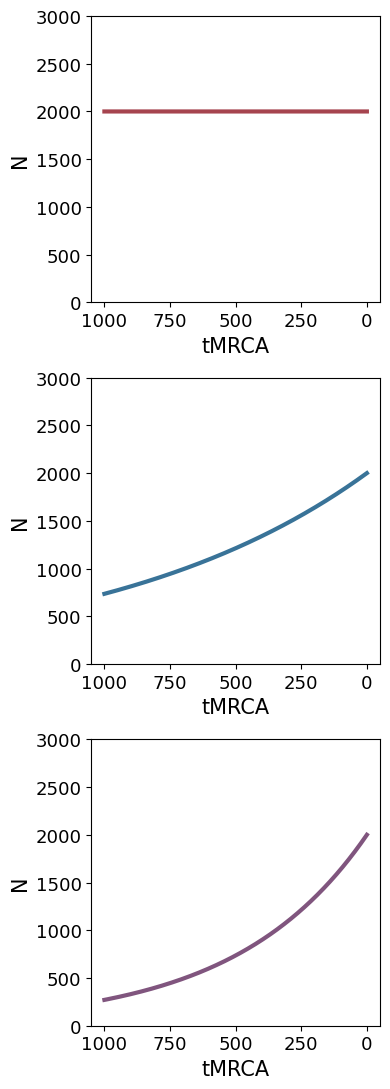

In [ ]:
# for simulation study

t_max = 1000
N_present = 10000

colors = ["#a6444f", "#397398", "#80557e", "#57a8b8"]  # Constant, Exp. growth, Exp. decline, Bottleneck

t_values = np.linspace(0, t_max, t_max * 10)

# Define models
models = {
    "Constant": np.repeat(2000, len(t_values)),
    "Slow exponential growth": 2000 * np.exp(-0.001 * t_values),
    "Fast exponential growth": 2000 * np.exp(-0.002 * t_values)}

fig, axes = plt.subplots(3, 1, figsize=(4,11), sharey=True)

for ax, (title, values), color in zip(axes, models.items(), colors):
    ax.plot(t_values, values, color=color, linewidth=3)
    #ax.set_title(title, fontsize=18)
    ax.set_xlabel("tMRCA", fontsize=15)
    ax.set_ylabel("N", fontsize=15)
    ax.set_ylim(0, 3000)
    ax.tick_params(labelleft=True, labelsize=13)
    ax.invert_xaxis()  # 👈 mirror the x-axis

plt.tight_layout()
plt.show()


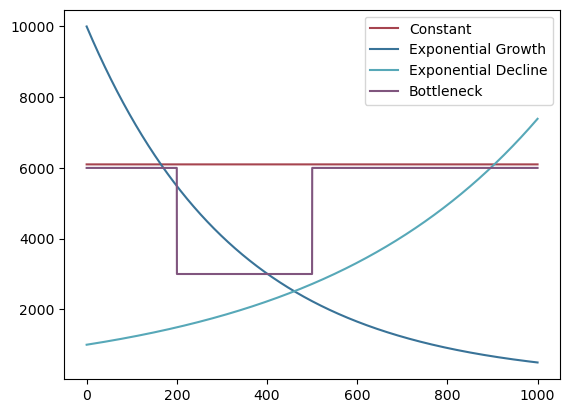

In [17]:
t_max = 1000
N_present = 10000

colors = ["#a6444f", "#397398", "#80557e", "#57a8b8"]  # Constant, Exp. growth, Exp. decline, Bottleneck

t_values = np.linspace(0, t_max, t_max * 10)
plt.plot(t_values, np.repeat(6100, len(t_values)), label= 'Constant', color = colors[0])
plt.plot(t_values, N_present * np.exp(-0.003 * t_values), label= 'Exponential Growth', color = colors[1])
plt.plot(t_values, 1000* np.exp(0.002 * t_values), label= 'Exponential Decline', color = colors[3])
plt.plot(t_values, np.where((t_values < 200) | (t_values > 500), 6000, 3000), color = colors[2], label= 'Bottleneck')
plt.legend()